<a href="https://colab.research.google.com/github/gabriela0402/ai-interview-evaluator/blob/main/notebooks/01_primeira_avaliacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Interview Evaluator — Setup

Este notebook prepara o ambiente inicial do projeto.

Nesta etapa, vamos apenas instalar as bibliotecas e verificar se o Colab está funcionando.


In [20]:
%pip install -q openai pandas pydantic python-dotenv scikit-learn matplotlib seaborn


In [21]:
import sys
import pandas as pd
import sklearn

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("Ambiente configurado com sucesso!")


Python: 3.13.15
Pandas: 2.2.3
Scikit-learn: 1.6.1
Ambiente configurado com sucesso!


In [22]:
import pandas as pd

dados = [
    {
        "id": "resp_001",
        "pergunta": "Conte sobre uma situação em que você precisou resolver um problema.",
        "competencia": "resolucao_de_problemas",
        "resposta": (
            "Durante um trabalho em grupo, percebemos que os dados estavam inconsistentes "
            "no dia anterior à apresentação. Eu conferi as fontes, encontrei os valores "
            "incorretos e organizei uma divisão de tarefas para corrigirmos tudo. "
            "Conseguimos finalizar a apresentação no prazo."
        ),
        "nivel_esperado": 5
    },
    {
        "id": "resp_002",
        "pergunta": "Conte sobre uma situação em que você precisou resolver um problema.",
        "competencia": "resolucao_de_problemas",
        "resposta": (
            "Uma vez tive um problema em um trabalho e tentei resolver pesquisando na internet. "
            "No final, consegui entregar, mas não lembro exatamente quais passos segui."
        ),
        "nivel_esperado": 3
    },
    {
        "id": "resp_003",
        "pergunta": "Conte sobre uma situação em que você precisou resolver um problema.",
        "competencia": "resolucao_de_problemas",
        "resposta": "Já tive problemas antes, mas normalmente outra pessoa resolve para mim.",
        "nivel_esperado": 1
    },
    {
        "id": "resp_004",
        "pergunta": "Fale sobre uma situação em que você trabalhou em equipe.",
        "competencia": "trabalho_em_equipe",
        "resposta": (
            "Em um projeto da faculdade, cada pessoa ficou responsável por uma parte. "
            "Eu organizei uma reunião para alinharmos as tarefas e ajudei um colega que "
            "estava com dificuldade. No final, conseguimos entregar o projeto juntos."
        ),
        "nivel_esperado": 5
    },
    {
        "id": "resp_005",
        "pergunta": "Fale sobre uma situação em que você trabalhou em equipe.",
        "competencia": "trabalho_em_equipe",
        "resposta": (
            "Já fiz trabalhos em grupo. Cada pessoa fez sua parte e depois juntamos tudo."
        ),
        "nivel_esperado": 3
    },
    {
        "id": "resp_006",
        "pergunta": "Fale sobre uma situação em que você trabalhou em equipe.",
        "competencia": "trabalho_em_equipe",
        "resposta": "Prefiro fazer trabalhos sozinho porque é mais fácil.",
        "nivel_esperado": 1
    },
    {
        "id": "resp_007",
        "pergunta": "Como você lida com um prazo curto?",
        "competencia": "organizacao",
        "resposta": (
            "Primeiro verifico tudo o que precisa ser feito e separo as tarefas por prioridade. "
            "Depois defino o que consigo concluir no prazo e comunico possíveis riscos antes "
            "que eles se tornem um problema."
        ),
        "nivel_esperado": 5
    },
    {
        "id": "resp_008",
        "pergunta": "Como você lida com um prazo curto?",
        "competencia": "organizacao",
        "resposta": (
            "Quando tenho pouco tempo, tento fazer as tarefas mais importantes primeiro, "
            "mas nem sempre consigo organizar tudo."
        ),
        "nivel_esperado": 3
    },
    {
        "id": "resp_009",
        "pergunta": "Como você lida com um prazo curto?",
        "competencia": "organizacao",
        "resposta": "Faço tudo correndo e entrego o que conseguir.",
        "nivel_esperado": 1
    }
]

dataset = pd.DataFrame(dados)

dataset


,id,pergunta,competencia,resposta,nivel_esperado
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",5
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,3
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",1
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",5
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,3
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Prefiro fazer trabalhos sozinho porque é mais ...,1
6,resp_007,Como você lida com um prazo curto?,organizacao,Primeiro verifico tudo o que precisa ser feito...,5
7,resp_008,Como você lida com um prazo curto?,organizacao,"Quando tenho pouco tempo, tento fazer as taref...",3
8,resp_009,Como você lida com um prazo curto?,organizacao,Faço tudo correndo e entrego o que conseguir.,1


In [23]:
print(f"Quantidade de respostas: {len(dataset)}")
print("\nQuantidade por competência:")
print(dataset["competencia"].value_counts())

print("\nDistribuição dos níveis:")
print(dataset["nivel_esperado"].value_counts().sort_index())


Quantidade de respostas: 9

Quantidade por competência:
competencia
resolucao_de_problemas    3
trabalho_em_equipe        3
organizacao               3
Name: count, dtype: int64

Distribuição dos níveis:
nivel_esperado
1    3
3    3
5    3
Name: count, dtype: int64


In [24]:
dataset.to_json(
    "entrevista_dataset_inicial.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

print("Dataset salvo como entrevista_dataset_inicial.jsonl")


Dataset salvo como entrevista_dataset_inicial.jsonl


In [25]:
from google.colab import files

files.download("entrevista_dataset_inicial.jsonl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import pandas as pd

url_dataset = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/data/sample/entrevista_dataset_inicial.jsonl"
 )

dataset = pd.read_json(url_dataset, lines=True)

print(f"Dataset carregado com sucesso!")
print(f"Quantidade de respostas: {len(dataset)}")

dataset.head()


Dataset carregado com sucesso!
Quantidade de respostas: 9


,id,pergunta,competencia,resposta,nivel_esperado
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",5
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,3
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",1
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",5
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,3


In [27]:
print("Colunas:")
print(list(dataset.columns))

print("\nRespostas por competência:")
print(dataset["competencia"].value_counts())

print("\nNíveis esperados:")
print(sorted(dataset["nivel_esperado"].unique()))


Colunas:
['id', 'pergunta', 'competencia', 'resposta', 'nivel_esperado']

Respostas por competência:
competencia
resolucao_de_problemas    3
trabalho_em_equipe        3
organizacao               3
Name: count, dtype: int64

Níveis esperados:
[np.int64(1), np.int64(3), np.int64(5)]


In [28]:
%pip install -q openai


In [29]:
from google.colab import userdata
from openai import OpenAI

token_hf = userdata.get("HF_TOKEN")

if not token_hf:
    raise ValueError(
        "O segredo HF_TOKEN não foi encontrado nos Secrets do Colab."
    )

cliente_hf = OpenAI(
    api_key=token_hf,
    base_url="https://router.huggingface.co/v1"
 )

modelo_hf = "openai/gpt-oss-20b"

print("Cliente da Hugging Face configurado com sucesso!")


Cliente da Hugging Face configurado com sucesso!


In [30]:
resposta_teste_hf = cliente_hf.chat.completions.create(
    model=modelo_hf,
    messages=[
        {
            "role": "user",
            "content": "Responda somente: conexão funcionando."
        }
    ],
    temperature=0,
    max_tokens=100
)

print(repr(resposta_teste_hf.choices[0].message.content))


'conexão funcionando.'


In [31]:
resposta_exemplo = dataset.iloc[0]

print("Pergunta:")
print(resposta_exemplo["pergunta"])

print("\nResposta:")
print(resposta_exemplo["resposta"])


Pergunta:
Conte sobre uma situação em que você precisou resolver um problema.

Resposta:
Durante um trabalho em grupo, percebemos que os dados estavam inconsistentes no dia anterior à apresentação. Eu conferi as fontes, encontrei os valores incorretos e organizei uma divisão de tarefas para corrigirmos tudo. Conseguimos finalizar a apresentação no prazo.


In [32]:
def avaliar_resposta(linha):
    prompt = f"""
Você é um avaliador auxiliar de entrevistas de emprego.

Avalie a resposta abaixo usando uma escala de 1 a 5 para cada critério.

Critérios:
1. relevancia: a resposta responde diretamente à pergunta?
2. especificidade: apresenta detalhes concretos e evidências?
3. comunicacao: é clara, organizada e compreensível?
4. reflexao: demonstra aprendizado ou análise da situação?
5. resultado: explica as consequências ou resultados das ações?

Não avalie aparência, nome, idade, gênero, origem ou qualquer característica pessoal.
Avalie somente o conteúdo da resposta.

Pergunta:
{linha["pergunta"]}

Competência avaliada:
{linha["competencia"]}

Resposta do candidato:
{linha["resposta"]}

Responda em português usando este formato:

Relevância: [nota de 1 a 5]
Especificidade: [nota de 1 a 5]
Comunicação: [nota de 1 a 5]
Reflexão: [nota de 1 a 5]
Resultado: [nota de 1 a 5]
Nota geral: [média aproximada]
Pontos fortes: [lista breve]
Pontos a melhorar: [lista breve]
Justificativa: [explicação breve]
"""

    resultado = cliente_hf.chat.completions.create(
        model=modelo_hf,
        messages=[
            {
                "role": "system",
                "content": (
                    "Você é um avaliador objetivo e consistente. "
                    "Sua avaliação é apenas uma sugestão experimental."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        max_tokens=500
    )

    return resultado.choices[0].message.content


In [33]:
avaliacao = avaliar_resposta(dataset.iloc[0])

print(avaliacao)


Relevância: 5  
Especificidade: 3  
Comunicação: 4  
Reflexão: 2  
Resultado: 3  
Nota geral: 3.4  

Pontos fortes:  
- Resposta diretamente relacionada à pergunta.  
- Comunicação clara e organizada.  
- Concluiu a tarefa dentro do prazo.  

Pontos a melhorar:  
- Falta de detalhes concretos (ex.: quais dados, quais fontes, quantas tarefas).  
- Ausência de reflexão sobre o que aprendeu ou como a experiência pode ser aplicada futuramente.  
- Resultados poderiam ser mais quantitativos ou qualitativos (ex.: impacto na apresentação, feedback da equipe).  

Justificativa:  
O candidato demonstra que identificou e resolveu um problema em equipe, mas a resposta carece de profundidade em termos de especificidade e reflexão. A comunicação é boa, mas a falta de detalhes e de análise de aprendizado limita a


In [34]:
import time


resultados = []

for indice, linha in dataset.iterrows():
    print(f"Avaliando resposta {indice + 1} de {len(dataset)}...")

    try:
        avaliacao = avaliar_resposta(linha)

        resultados.append({
            "id": linha["id"],
            "pergunta": linha["pergunta"],
            "competencia": linha["competencia"],
            "nivel_esperado": linha["nivel_esperado"],
            "avaliacao_modelo": avaliacao,
            "status": "sucesso"
        })

    except Exception as erro:
        resultados.append({
            "id": linha["id"],
            "pergunta": linha["pergunta"],
            "competencia": linha["competencia"],
            "nivel_esperado": linha["nivel_esperado"],
            "avaliacao_modelo": None,
            "status": f"erro: {erro}"
        })

    time.sleep(2)

resultados_df = pd.DataFrame(resultados)

print("Processamento concluído!")
display(resultados_df)


Avaliando resposta 1 de 9...
Avaliando resposta 2 de 9...
Avaliando resposta 3 de 9...
Avaliando resposta 4 de 9...
Avaliando resposta 5 de 9...
Avaliando resposta 6 de 9...
Avaliando resposta 7 de 9...
Avaliando resposta 8 de 9...
Avaliando resposta 9 de 9...
Processamento concluído!


,id,pergunta,competencia,nivel_esperado,avaliacao_modelo,status
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,5,Relevância: 5 \nEspecificidade: 3 \nComunica...,sucesso
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,3,Relevância: 3 \nEspecificidade: 1 \nComunica...,sucesso
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,1,Relevância: 1 \nEspecificidade: 1 \nComunica...,sucesso
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,5,Relevância: 5 \nEspecificidade: 2 \nComunica...,sucesso
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,3,Relevância: 4 \nEspecificidade: 1 \nComunica...,sucesso
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,1,Relevância: 1 \nEspecificidade: 1 \nComunica...,sucesso
6,resp_007,Como você lida com um prazo curto?,organizacao,5,Relevância: 4 \nEspecificidade: 3 \nComunica...,sucesso
7,resp_008,Como você lida com um prazo curto?,organizacao,3,None,erro: Error code: 402 - {'error': 'You have de...
8,resp_009,Como você lida com um prazo curto?,organizacao,1,None,erro: Error code: 402 - {'error': 'You have de...


In [37]:
resultados_df.to_json(
    "resultados_avaliacao_parcial.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

print("Resultado parcial salvo com sucesso.")


Resultado parcial salvo com sucesso.


In [38]:
from google.colab import files

files.download("resultados_avaliacao_parcial.jsonl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
resultados_sucesso = resultados_df[
    resultados_df["status"] == "sucesso"
].copy()

print(f"Respostas avaliadas com sucesso: {len(resultados_sucesso)}")

display(
    resultados_sucesso[
        ["id", "competencia", "nivel_esperado", "avaliacao_modelo"]
    ]
)


Respostas avaliadas com sucesso: 7


,id,competencia,nivel_esperado,avaliacao_modelo
0,resp_001,resolucao_de_problemas,5,Relevância: 5 \nEspecificidade: 3 \nComunica...
1,resp_002,resolucao_de_problemas,3,Relevância: 3 \nEspecificidade: 1 \nComunica...
2,resp_003,resolucao_de_problemas,1,Relevância: 1 \nEspecificidade: 1 \nComunica...
3,resp_004,trabalho_em_equipe,5,Relevância: 5 \nEspecificidade: 2 \nComunica...
4,resp_005,trabalho_em_equipe,3,Relevância: 4 \nEspecificidade: 1 \nComunica...
5,resp_006,trabalho_em_equipe,1,Relevância: 1 \nEspecificidade: 1 \nComunica...
6,resp_007,organizacao,5,Relevância: 4 \nEspecificidade: 3 \nComunica...


In [40]:
print(resultados_sucesso.iloc[0]["avaliacao_modelo"])


Relevância: 5  
Especificidade: 3  
Comunicação: 4  
Reflexão: 2  
Resultado: 3  
Nota geral: 3.4  

Pontos fortes:  
- Resposta diretamente relacionada à pergunta.  
- Comunicação clara e organizada.  
- Concluiu a tarefa dentro do prazo.  

Pontos a melhorar:  
- Falta de detalhes concretos (ex.: quais dados, quais fontes, quantas tarefas).  
- Ausência de reflexão sobre o que aprendeu ou como a experiência pode ser aplicada futuramente.  
- Resultados poderiam ser mais quantitativos ou qualitativos (ex.: impacto na apresentação, feedback da equipe).  

Justificativa:  
O candidato demonstra que identificou e resolveu um problema em equipe, mas a resposta carece de profundidade em termos de especificidade e reflexão. A comunicação é boa, mas a falta de detalhes e de análise de aprendizado limita a


In [45]:
import re
import numpy as np

def extrair_nota(texto, criterio):
    padrao = rf"{criterio}\s*:\s*([1-5](?:[.,]\d+)?)"

    resultado = re.search(padrao, texto, flags=re.IGNORECASE)

    if resultado:
        return float(resultado.group(1).replace(",", "."))


    return np.nan


def extrair_avaliacao(texto):
    return {
        "nota_relevancia": extrair_nota(texto, "Relevância"),
        "nota_especificidade": extrair_nota(texto, "Especificidade"),
        "nota_comunicacao": extrair_nota(texto, "Comunicação"),
        "nota_reflexao": extrair_nota(texto, "Reflexão"),
        "nota_resultado": extrair_nota(texto, "Resultado"),
        "nota_geral": extrair_nota(texto, "Nota geral")
    }


In [42]:
notas_extraidas = resultados_sucesso["avaliacao_modelo"].apply(
    extrair_avaliacao
).apply(pd.Series)

resultados_analisaveis = pd.concat(
    [
        resultados_sucesso.reset_index(drop=True),
        notas_extraidas
    ],
    axis=1
)

display(
    resultados_analisaveis[
        [
            "id",
            "competencia",
            "nivel_esperado",
            "nota_relevancia",
            "nota_especificidade",
            "nota_comunicacao",
            "nota_reflexao",
            "nota_resultado",
            "nota_geral"
        ]
    ]
)


,id,competencia,nivel_esperado,nota_relevancia,nota_especificidade,nota_comunicacao,nota_reflexao,nota_resultado,nota_geral
0,resp_001,resolucao_de_problemas,5,5,3,4,2,3,3
1,resp_002,resolucao_de_problemas,3,3,1,3,1,2,2
2,resp_003,resolucao_de_problemas,1,1,1,2,1,1,1
3,resp_004,trabalho_em_equipe,5,5,2,4,1,2,3
4,resp_005,trabalho_em_equipe,3,4,1,3,1,1,2
5,resp_006,trabalho_em_equipe,1,1,1,2,1,1,1
6,resp_007,organizacao,5,4,3,4,2,2,3


In [46]:
comparacao = resultados_analisaveis[
    ["id", "competencia", "nivel_esperado", "nota_geral"]
].copy()

comparacao["diferenca"] = (
    comparacao["nota_geral"] - comparacao["nivel_esperado"]
)

comparacao["erro_absoluto"] = comparacao["diferenca"].abs()

display(comparacao)


,id,competencia,nivel_esperado,nota_geral,diferenca,erro_absoluto
0,resp_001,resolucao_de_problemas,5,3,-2,2
1,resp_002,resolucao_de_problemas,3,2,-1,1
2,resp_003,resolucao_de_problemas,1,1,0,0
3,resp_004,trabalho_em_equipe,5,3,-2,2
4,resp_005,trabalho_em_equipe,3,2,-1,1
5,resp_006,trabalho_em_equipe,1,1,0,0
6,resp_007,organizacao,5,3,-2,2


In [47]:
mae = comparacao["erro_absoluto"].mean()
diferenca_media = comparacao["diferenca"].mean()

print(f"Erro médio absoluto: {mae:.2f}")
print(f"Diferença média entre IA e referência: {diferenca_media:.2f}")


Erro médio absoluto: 1.14
Diferença média entre IA e referência: -1.14


In [48]:
media_competencias = (
    resultados_analisaveis
    .groupby("competencia")[
        ["nivel_esperado", "nota_geral"]
    ]
    .mean()
    .round(2)
)

display(media_competencias)


,nivel_esperado,nota_geral
competencia,,
organizacao,5.0,3.0
resolucao_de_problemas,3.0,2.0
trabalho_em_equipe,3.0,2.0


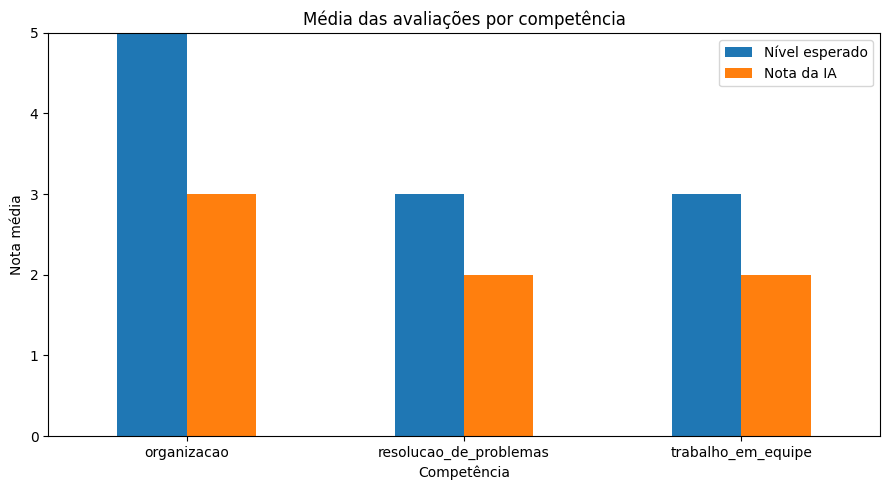

In [49]:
import matplotlib.pyplot as plt

media_competencias.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Média das avaliações por competência")
plt.xlabel("Competência")
plt.ylabel("Nota média")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.legend(["Nível esperado", "Nota da IA"])
plt.tight_layout()
plt.show()


In [52]:
total_respostas = len(resultados_df)
total_sucesso = len(resultados_sucesso)
total_erros = total_respostas - total_sucesso

relatorio = f"""
# Relatório do primeiro experimento

## Objetivo

Avaliar respostas de entrevistas comportamentais usando um modelo de linguagem
e comparar suas notas com um nível de referência do dataset sintético.

## Dataset

O experimento utilizou {total_respostas} respostas sintéticas.

## Resultados do processamento

- Respostas processadas: {total_respostas}
- Respostas avaliadas com sucesso: {total_sucesso}
- Respostas não avaliadas: {total_erros}
- Erro médio absoluto: {mae:.2f}
- Diferença média entre a IA e a referência: {diferenca_media:.2f}

## Médias por competência

{media_competencias.to_string()}

## Limitação relacionada à API

Duas respostas não puderam ser avaliadas porque os créditos gratuitos da
Hugging Face foram esgotados durante o processamento.

A API retornou o erro HTTP 402, indicando que a cota mensal gratuita havia
sido consumida.

Por esse motivo, os resultados deste experimento são parciais e não
representam uma avaliação completa das nove respostas.

## Limitações metodológicas

- O dataset é sintético e pequeno.
- O nível esperado foi definido inicialmente por nós.
- Não houve uma amostra ampla de avaliadores humanos.
- A avaliação foi feita por apenas um modelo.
- Os resultados não devem ser usados para decisões reais de contratação.
- A nota da IA pode ser influenciada pelo prompt e pelo modelo utilizado.

## Próximos passos

- Criar avaliações humanas para comparação.
- Testar um modelo local gratuito.
- Melhorar o formato estruturado das respostas.
- Investigar consistência e possíveis vieses.
"""

with open(
    "relatorio_primeiro_experimento.md",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(relatorio)

print("Relatório criado com sucesso!")
print(relatorio)


Relatório criado com sucesso!

# Relatório do primeiro experimento

## Objetivo

Avaliar respostas de entrevistas comportamentais usando um modelo de linguagem
e comparar suas notas com um nível de referência do dataset sintético.

## Dataset

O experimento utilizou 9 respostas sintéticas.

## Resultados do processamento

- Respostas processadas: 9
- Respostas avaliadas com sucesso: 7
- Respostas não avaliadas: 2
- Erro médio absoluto: 1.14
- Diferença média entre a IA e a referência: -1.14

## Médias por competência

                        nivel_esperado  nota_geral
competencia                                       
organizacao                        5.0         3.0
resolucao_de_problemas             3.0         2.0
trabalho_em_equipe                 3.0         2.0

## Limitação relacionada à API

Duas respostas não puderam ser avaliadas porque os créditos gratuitos da
Hugging Face foram esgotados durante o processamento.

A API retornou o erro HTTP 402, indicando que a cota mensal 

In [53]:
from google.colab import files

files.download("relatorio_primeiro_experimento.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
avaliacoes_manuais = resultados_sucesso[
    ["id", "pergunta", "competencia"]
].copy()

avaliacoes_manuais = avaliacoes_manuais.merge(
    dataset[["id", "resposta"]],
    on="id",
    how="left"
)

avaliacoes_manuais["nota_relevancia_manual"] = ""
avaliacoes_manuais["nota_especificidade_manual"] = ""
avaliacoes_manuais["nota_comunicacao_manual"] = ""
avaliacoes_manuais["nota_reflexao_manual"] = ""
avaliacoes_manuais["nota_resultado_manual"] = ""
avaliacoes_manuais["observacao_manual"] = ""

display(avaliacoes_manuais)


,id,pergunta,competencia,resposta,nota_relevancia_manual,nota_especificidade_manual,nota_comunicacao_manual,nota_reflexao_manual,nota_resultado_manual,observacao_manual
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",,,,,,
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,,,,,,
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",,,,,,
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",,,,,,
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,,,,,,
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Prefiro fazer trabalhos sozinho porque é mais ...,,,,,,
6,resp_007,Como você lida com um prazo curto?,organizacao,Primeiro verifico tudo o que precisa ser feito...,,,,,,


In [56]:
avaliacoes_manuais.to_csv(
    "avaliacoes_manuais.csv",
    index=False,
    encoding="utf-8-sig"
)

from google.colab import files

files.download("avaliacoes_manuais.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
avaliacoes_referencia = {
    "resp_001": {
        "nota_relevancia_manual": 5,
        "nota_especificidade_manual": 5,
        "nota_comunicacao_manual": 5,
        "nota_reflexao_manual": 3,
        "nota_resultado_manual": 4,
        "observacao_manual": (
            "Apresenta contexto, ações concretas e resultado. "
            "Poderia explicar melhor o que aprendeu com a situação."
        )
    },
    "resp_002": {
        "nota_relevancia_manual": 4,
        "nota_especificidade_manual": 3,
        "nota_comunicacao_manual": 3,
        "nota_reflexao_manual": 2,
        "nota_resultado_manual": 2,
        "observacao_manual": (
            "Responde à pergunta, mas apresenta poucos detalhes e não explica "
            "claramente as ações nem o resultado."
        )
    },
    "resp_003": {
        "nota_relevancia_manual": 2,
        "nota_especificidade_manual": 1,
        "nota_comunicacao_manual": 3,
        "nota_reflexao_manual": 1,
        "nota_resultado_manual": 1,
        "observacao_manual": (
            "A resposta é curta e não apresenta uma situação concreta, ações "
            "realizadas ou resultado."
        )
    },
    "resp_004": {
        "nota_relevancia_manual": 5,
        "nota_especificidade_manual": 5,
        "nota_comunicacao_manual": 5,
        "nota_reflexao_manual": 3,
        "nota_resultado_manual": 4,
        "observacao_manual": (
            "Demonstra colaboração, organização e apoio a um colega. "
            "Apresenta um resultado, mas poderia detalhar melhor o aprendizado."
        )
    },
    "resp_005": {
        "nota_relevancia_manual": 4,
        "nota_especificidade_manual": 2,
        "nota_comunicacao_manual": 4,
        "nota_reflexao_manual": 2,
        "nota_resultado_manual": 3,
        "observacao_manual": (
            "Responde ao tema, mas é genérica e não deixa claro qual foi a "
            "contribuição individual do candidato."
        )
    },
    "resp_006": {
        "nota_relevancia_manual": 2,
        "nota_especificidade_manual": 1,
        "nota_comunicacao_manual": 3,
        "nota_reflexao_manual": 1,
        "nota_resultado_manual": 1,
        "observacao_manual": (
            "Não apresenta um exemplo de trabalho em equipe e demonstra "
            "preferência por trabalhar sozinho."
        )
    },
    "resp_007": {
        "nota_relevancia_manual": 5,
        "nota_especificidade_manual": 4,
        "nota_comunicacao_manual": 5,
        "nota_reflexao_manual": 4,
        "nota_resultado_manual": 4,
        "observacao_manual": (
            "Apresenta uma estratégia clara de priorização e comunicação de riscos. "
            "Poderia incluir um exemplo real para fortalecer a resposta."
        )
    }
}

for id_resposta, avaliacao in avaliacoes_referencia.items():
    for coluna, valor in avaliacao.items():
        avaliacoes_manuais.loc[
            avaliacoes_manuais["id"] == id_resposta,
            coluna
        ] = valor

display(avaliacoes_manuais)


,id,pergunta,competencia,resposta,nota_relevancia_manual,nota_especificidade_manual,nota_comunicacao_manual,nota_reflexao_manual,nota_resultado_manual,observacao_manual
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",5,5,5,3,4,"Apresenta contexto, ações concretas e resultad..."
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,4,3,3,2,2,"Responde à pergunta, mas apresenta poucos deta..."
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",2,1,3,1,1,A resposta é curta e não apresenta uma situaçã...
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",5,5,5,3,4,"Demonstra colaboração, organização e apoio a u..."
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,4,2,4,2,3,"Responde ao tema, mas é genérica e não deixa c..."
5,resp_006,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Prefiro fazer trabalhos sozinho porque é mais ...,2,1,3,1,1,Não apresenta um exemplo de trabalho em equipe...
6,resp_007,Como você lida com um prazo curto?,organizacao,Primeiro verifico tudo o que precisa ser feito...,5,4,5,4,4,Apresenta uma estratégia clara de priorização ...


In [58]:
avaliacoes_manuais.to_csv(
    "avaliacoes_manuais.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Avaliações de referência preenchidas e salvas.")


Avaliações de referência preenchidas e salvas.


In [59]:
from google.colab import files

files.download("avaliacoes_manuais.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import pandas as pd

colunas_ia = [
    "id",
    "nota_relevancia",
    "nota_especificidade",
    "nota_comunicacao",
    "nota_reflexao",
    "nota_resultado",
    "nota_geral"
]

colunas_manuais = [
    "id",
    "nota_relevancia_manual",
    "nota_especificidade_manual",
    "nota_comunicacao_manual",
    "nota_reflexao_manual",
    "nota_resultado_manual"
]

comparacao_notas = resultados_analisaveis[colunas_ia].merge(
    avaliacoes_manuais[colunas_manuais],
    on="id",
    how="inner"
)

display(comparacao_notas)


,id,nota_relevancia,nota_especificidade,nota_comunicacao,nota_reflexao,nota_resultado,nota_geral,nota_relevancia_manual,nota_especificidade_manual,nota_comunicacao_manual,nota_reflexao_manual,nota_resultado_manual
0,resp_001,5,3,4,2,3,3,5,5,5,3,4
1,resp_002,3,1,3,1,2,2,4,3,3,2,2
2,resp_003,1,1,2,1,1,1,2,1,3,1,1
3,resp_004,5,2,4,1,2,3,5,5,5,3,4
4,resp_005,4,1,3,1,1,2,4,2,4,2,3
5,resp_006,1,1,2,1,1,1,2,1,3,1,1
6,resp_007,4,3,4,2,2,3,5,4,5,4,4


In [61]:
colunas_notas = [
    "nota_relevancia",
    "nota_especificidade",
    "nota_comunicacao",
    "nota_reflexao",
    "nota_resultado",
    "nota_geral",
    "nota_relevancia_manual",
    "nota_especificidade_manual",
    "nota_comunicacao_manual",
    "nota_reflexao_manual",
    "nota_resultado_manual"
]

for coluna in colunas_notas:
    comparacao_notas[coluna] = pd.to_numeric(
        comparacao_notas[coluna],
        errors="coerce"
    )


In [62]:
colunas_manuais_criterios = [
    "nota_relevancia_manual",
    "nota_especificidade_manual",
    "nota_comunicacao_manual",
    "nota_reflexao_manual",
    "nota_resultado_manual"
]

comparacao_notas["nota_geral_manual"] = (
    comparacao_notas[colunas_manuais_criterios]
    .mean(axis=1)
)

display(
    comparacao_notas[
        ["id", "nota_geral", "nota_geral_manual"]
    ]
)


,id,nota_geral,nota_geral_manual
0,resp_001,3,4.4
1,resp_002,2,2.8
2,resp_003,1,1.6
3,resp_004,3,4.4
4,resp_005,2,3.0
5,resp_006,1,1.6
6,resp_007,3,4.4


In [63]:
dados_correlacao = comparacao_notas[
    ["nota_geral", "nota_geral_manual"]
].dropna()

correlacao_spearman = dados_correlacao.corr(
    method="spearman"
).iloc[0, 1]

correlacao_pearson = dados_correlacao.corr(
    method="pearson"
).iloc[0, 1]

print(f"Correlação de Spearman: {correlacao_spearman:.2f}")
print(f"Correlação de Pearson: {correlacao_pearson:.2f}")


Correlação de Spearman: 0.99
Correlação de Pearson: 1.00


In [64]:
criterios = {
    "relevancia": (
        "nota_relevancia",
        "nota_relevancia_manual"
    ),
    "especificidade": (
        "nota_especificidade",
        "nota_especificidade_manual"
    ),
    "comunicacao": (
        "nota_comunicacao",
        "nota_comunicacao_manual"
    ),
    "reflexao": (
        "nota_reflexao",
        "nota_reflexao_manual"
    ),
    "resultado": (
        "nota_resultado",
        "nota_resultado_manual"
    )
}

correlacoes = []

for criterio, (coluna_ia, coluna_manual) in criterios.items():
    dados = comparacao_notas[
        [coluna_ia, coluna_manual]
    ].dropna()

    correlacao = dados[coluna_ia].corr(
        dados[coluna_manual],
        method="spearman"
    )

    correlacoes.append({
        "criterio": criterio,
        "correlacao_spearman": correlacao,
        "quantidade_respostas": len(dados)
    })

correlacoes_df = pd.DataFrame(correlacoes)

display(correlacoes_df)


,criterio,correlacao_spearman,quantidade_respostas
0,relevancia,0.922722,7
1,especificidade,0.821584,7
2,comunicacao,0.938971,7
3,reflexao,0.731372,7
4,resultado,0.768029,7
